In [1]:
from datasets import load_dataset
ds = load_dataset("imdb")
df = ds["train"].to_pandas()
df.to_csv("imdb_train.csv", index=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
#warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                               ConfusionMatrixDisplay, f1_score)
from wordcloud import WordCloud

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
from datasets import load_dataset

print("Loading IMDb dataset (50,000 reviews)...")
dataset = load_dataset("imdb")
print("Dataset loaded successfully!")
df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()
df = pd.concat([df_train, df_test], ignore_index=True)
df['sentiment'] = df['label'].map({0: 'negative', 1: 'positive'})
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Loading IMDb dataset (50,000 reviews)...
Dataset shape: (50000, 3)
Columns: ['text', 'label', 'sentiment']


,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative


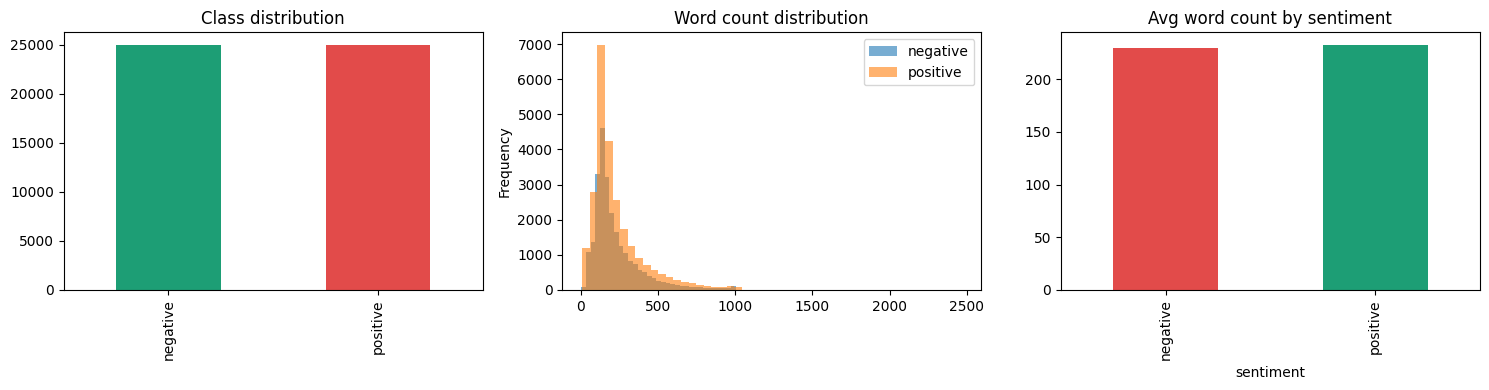

       word_count  review_len
count     50000.0     50000.0
mean        231.2      1309.4
std         171.3       989.7
min           4.0        32.0
25%         126.0       699.0
50%         173.0       970.0
75%         280.0      1590.2
max        2470.0     13704.0


In [4]:
df['review_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#1D9E75', '#E24B4A'], edgecolor='none')
axes[0].set_title('Class distribution')
axes[0].set_xlabel('')

df.groupby('sentiment')['word_count'].plot(
    kind='hist', bins=50, alpha=0.6, ax=axes[1])
axes[1].set_title('Word count distribution')
axes[1].legend(['negative', 'positive'])

df.groupby('sentiment')['word_count'].mean().plot(
    kind='bar', ax=axes[2],
    color=['#E24B4A', '#1D9E75'], edgecolor='none')
axes[2].set_title('Avg word count by sentiment')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print(df[['word_count','review_len']].describe().round(1))

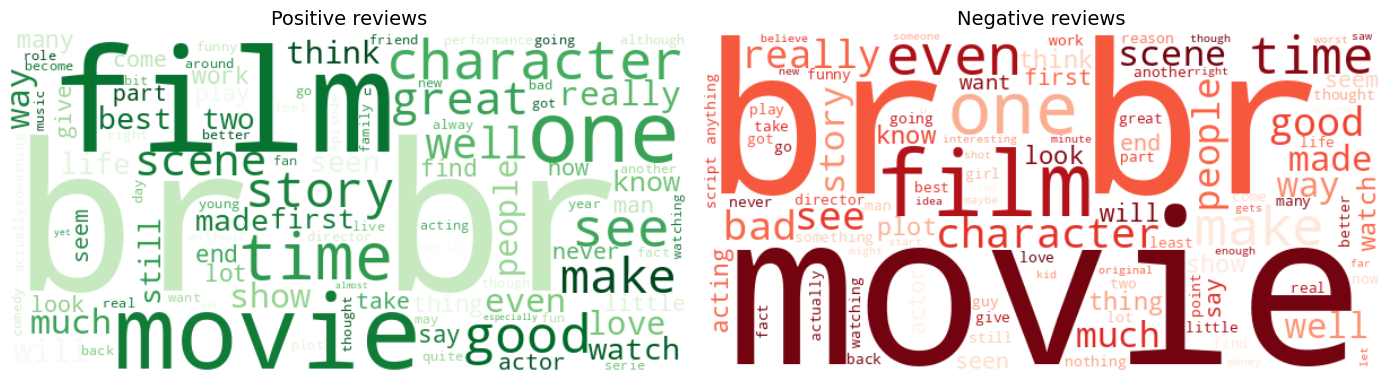

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sentiment, color in zip(axes,
        ['positive', 'negative'], ['Greens', 'Reds']):
    text = ' '.join(df[df['sentiment'] == sentiment]['text'].sample(2000))
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap=color, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment.capitalize()} reviews', fontsize=14)

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Remove stopwords and lemmatize
    return ' '.join(tokens)
df['clean_text'] = df['text'].apply(clean_text)
X = df['clean_text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)
print(f"Train size : {X_train_vec.shape}")
print(f"Test size  : {X_test_vec.shape}")
print(f"Vocabulary : {len(tfidf.vocabulary_):,} features")

Train size : (40000, 15000)
Test size  : (10000, 15000)
Vocabulary : 15,000 features


In [9]:
results = {}
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'accuracy': accuracy, 'f1': f1}
    print(f"{name} - Accuracy: {accuracy:.4f}, F1-score: {f1:.4f}")
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

Training Logistic Regression model...
Logistic Regression - Accuracy: 0.8978, F1-score: 0.8989


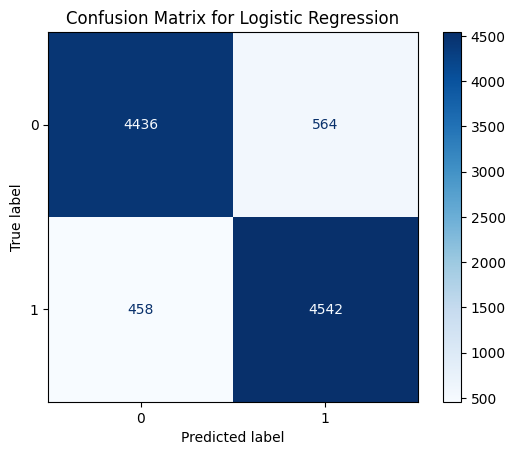

In [10]:
print('Training Logistic Regression model...')
lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
lr_model.fit(X_train_vec, y_train)
evaluate_model('Logistic Regression', lr_model, X_test_vec, y_test)

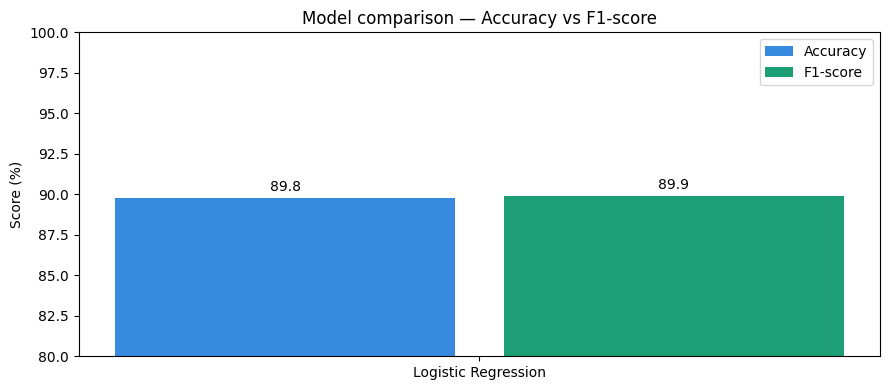

In [11]:
names = list(results.keys())
accs  = [results[n]['accuracy'] * 100 for n in names]
f1s   = [results[n]['f1'] * 100 for n in names]
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - 0.2, accs, 0.35, label='Accuracy', color='#378ADD')
bars2 = ax.bar(x + 0.2, f1s,  0.35, label='F1-score', color='#1D9E75')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(80, 100)
ax.set_ylabel('Score (%)')
ax.set_title('Model comparison — Accuracy vs F1-score')
ax.legend()
ax.bar_label(bars1, fmt='%.1f', padding=3)
ax.bar_label(bars2, fmt='%.1f', padding=3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
best_model = lr_model
def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    vec     = tfidf.transform([cleaned])
    pred    = best_model.predict(vec)[0]
    label   = "POSITIVE" if pred == 1 else "NEGATIVE"

    if hasattr(best_model, 'predict_proba'):
        prob = best_model.predict_proba(vec)[0].max()
        print(f"Sentiment : {label}  ({prob*100:.1f}% confidence)")
    else:
        print(f"Sentiment : {label}")

predict_sentiment("This movie was absolutely fantastic! The acting was superb.")
predict_sentiment("Terrible plot, boring characters, total waste of time.")
predict_sentiment("It was okay, not great but not terrible either.")

Sentiment : POSITIVE  (93.1% confidence)
Sentiment : NEGATIVE  (100.0% confidence)
Sentiment : NEGATIVE  (95.9% confidence)
